# 6.0 KeyRank — 128비트 키 전체의 순위 · Normal ∥ Masked

## 이 노트북이 답하는 질문

공격이 키 16바이트를 **전부 1등으로** 맞히지는 못했다고 하자. 그래도 각 바이트에서
정답이 상위권이라면, 남은 후보를 **전수조사**할 수 있을지 모른다.

**그 남은 일이 얼마나 되는가?** 즉 정답 키가 전체 $2^{128}$ 후보 중 몇 번째인가?

바이트별 순위를 곱하면 될 것 같지만 그렇지 않다. 전체 순위는 "각 바이트 점수의 합이
정답보다 좋은 조합이 몇 개인가" 이고, 이는 단순 곱셈으로 나오지 않는다.
`scalib.postprocessing` 의 `rank_accuracy` 와 `rank_nbin` 이 그 개수를 추정한다.

| | |
|---|---|
| 입력 | 4.1 MultiLDA 가 만든 바이트별 확률 |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 |

**이 노트북이 이 시리즈의 결론이다.** 지금까지는 "복구했다/못했다" 였지만, 여기서는
두 타겟의 방어력을 **남은 전수조사 비트 수**라는 하나의 축으로 비교한다.

## 비용(cost) 규약

두 함수 모두 **비용** 배열 `(ns, nc)` 를 받는다 — `ns` 는 부분키 개수(16), `nc` 는 후보 수(256).
**작을수록 좋은 값**이다. 확률에서 만들 때는 음의 로그확률을 쓴다.

$$ \text{cost}[i][g] \ =\ -\log \Pr[\ k_i = g\ ] $$

반환은 `(하한, 추정, 상한)` 세 값이다. 순위 추정은 근사이므로 구간으로 준다.

| 함수 | 방식 |
|------|------|
| `rank_accuracy(costs, key, acc_bit)` | 목표 **정확도**를 주면 그에 맞게 빈 수를 조절한다 |
| `rank_nbin(costs, key, nbins)` | 빈 수를 직접 준다 |

`acc_bit=1.0` 은 "상한/하한 비가 $2^1$ 이내가 되게" 라는 뜻이다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, AES_BLOCK, sbox_out,
    load_group, load_poi, group_len, dataset_summary, require_target,
)
from scalib.modeling import MultiLDA
from scalib.postprocessing import rank_accuracy, rank_nbin

P_DIM = 3
N_ATK = 500

AVAILABLE = {tid: group_len("profiling", tid) for tid in TARGET_IDS
             if require_target(tid)["dataset"].is_file()}
N_PROF = min(AVAILABLE.values())
print("프로파일링 보유:", {TARGETS[t]["short"]: n for t, n in AVAILABLE.items()})
print("→ 양쪽 모두 %d 장으로 맞춘다.\n" % N_PROF)

probas, atks = {}, {}
for tid in AVAILABLE:
    z = load_poi(tid)
    w = z["poi_windows"].astype(int)
    cols = np.unique(w.ravel())
    prof = load_group("profiling", target=tid, n=N_PROF, samples=cols)
    atk = load_group("attack", target=tid, n=N_ATK, samples=cols)
    loc = [np.searchsorted(cols, w[b]) for b in range(AES_BLOCK)]

    mlda = MultiLDA(ncs=[256] * AES_BLOCK, ps=[P_DIM] * AES_BLOCK, pois=loc)
    mlda.fit_u(np.ascontiguousarray(prof["t"]),
               sbox_out(prof["p"], prof["k"]).astype(np.uint16))
    mlda.solve()
    probas[tid] = mlda.predict_proba(np.ascontiguousarray(atk["t"]))
    atks[tid] = atk
    print("[%s] 템플릿 준비 완료 — 변수 %d개" % (TARGETS[tid]["short"], len(probas[tid])))

TRUE_KEY = np.array(atks[list(atks)[0]]["attrs"]["fixed_key"], dtype=np.uint8)

프로파일링 보유: {'Normal': 100000, 'Masked': 100000}
→ 양쪽 모두 100000 장으로 맞춘다.



[Normal] 템플릿 준비 완료 — 변수 16개


[Masked] 템플릿 준비 완료 — 변수 16개


---
## 1. 바이트별 비용 만들기

4.x 에서 쓴 로그확률 누적을 그대로 쓰되, 마지막에 **정규화한 뒤 부호를 뒤집어** 비용으로 만든다.
정규화를 하는 이유는 바이트마다 로그확률의 절대 크기가 달라 그대로 더하면
한 바이트가 전체를 지배할 수 있기 때문이다.

In [2]:
GUESS = np.arange(256, dtype=np.uint8)


def key_logprob_all(tid, n_use):
    """앞의 n_use 장으로 바이트별 키 후보 로그확률 (16, 256) 을 만든다."""
    pr, atk = probas[tid], atks[tid]
    out = np.zeros((AES_BLOCK, 256))
    for i in range(AES_BLOCK):
        lp = np.log(np.maximum(pr[i][:n_use], 1e-300))
        g = SBOX[np.bitwise_xor(atk["p"][:n_use, i][:, None], GUESS[None, :])]
        out[i] = np.take_along_axis(lp, g, axis=1).sum(axis=0)
    return out


def to_costs(logp):
    """로그확률 → 비용. 정규화 후 부호를 뒤집는다 (작을수록 좋음)."""
    z = logp - logp.max(axis=1, keepdims=True)
    p = np.exp(z)
    p /= p.sum(axis=1, keepdims=True)
    return -np.log(np.maximum(p, 1e-300))


N_USE = 3
for tid in probas:
    logp = key_logprob_all(tid, N_USE)
    ranks = np.array([(logp[i] > logp[i, TRUE_KEY[i]]).sum() for i in range(AES_BLOCK)])
    print("[%-8s] 공격 %d장  바이트별 순위 %s" % (
        TARGETS[tid]["short"], N_USE, ranks.tolist()))
    print("           1등으로 맞힌 바이트 %d/16   costs shape %s"
          % (int((ranks == 0).sum()), to_costs(logp).shape))

[Normal  ] 공격 3장  바이트별 순위 [0, 0, 0, 3, 1, 1, 2, 0, 0, 1, 0, 0, 3, 0, 0, 0]
           1등으로 맞힌 바이트 10/16   costs shape (16, 256)
[Masked  ] 공격 3장  바이트별 순위 [99, 62, 142, 197, 139, 12, 110, 170, 77, 243, 84, 12, 229, 185, 24, 122]
           1등으로 맞힌 바이트 0/16   costs shape (16, 256)


---
## 2. 전체 키 순위

바이트별로는 정답이 상위권이어도, 128비트 전체로는 남은 후보가 얼마나 되는가?

In [3]:
import time

print("%-8s %6s %14s %14s %14s %10s" % (
    "타겟", "장수", "하한", "추정", "상한", "log2(추정)"))
rank_curve = {}
for tid in probas:
    rows = []
    for m in (1, 2, 3, 5, 10, 30, 100):
        m = min(m, probas[tid][0].shape[0])
        costs = to_costs(key_logprob_all(tid, m))
        t0 = time.time()
        rmin, r, rmax = rank_accuracy(costs, TRUE_KEY, acc_bit=1.0)
        rows.append((m, float(rmin), float(r), float(rmax)))
        print("%-8s %6d %14.4g %14.4g %14.4g %10.2f" % (
            TARGETS[tid]["short"], m, rmin, r, rmax, np.log2(max(r, 1))))
    rank_curve[tid] = rows
    print()

print("log2(순위) 가 곧 '남은 전수조사 규모(비트)' 다.")
print("0 비트 = 정답이 1등, 128 비트 = 아무 정보도 못 얻은 상태.")

타겟           장수             하한             추정             상한   log2(추정)
Normal        1      2.863e+21      4.034e+21      5.611e+21      71.77
Normal        2      4.664e+10      5.909e+10      7.087e+10      35.78


Normal        3      1.723e+05      2.303e+05      3.059e+05      17.81


Normal        5              1              1              1       0.00
Normal       10              1              1              1       0.00
Normal       30              1              1              1       0.00
Normal      100              1              1              1       0.00

Masked        1      1.135e+38      1.373e+38      1.679e+38     126.69
Masked        2      1.124e+38      1.418e+38      1.807e+38     126.74


Masked        3       3.63e+37      4.494e+37      5.244e+37     125.08
Masked        5      8.509e+37      1.018e+38      1.198e+38     126.26
Masked       10      1.374e+37      1.795e+37      2.309e+37     123.76
Masked       30      1.111e+37      1.492e+37      1.967e+37     123.49


Masked      100      1.042e+37      1.332e+37      1.799e+37     123.33

log2(순위) 가 곧 '남은 전수조사 규모(비트)' 다.
0 비트 = 정답이 1등, 128 비트 = 아무 정보도 못 얻은 상태.


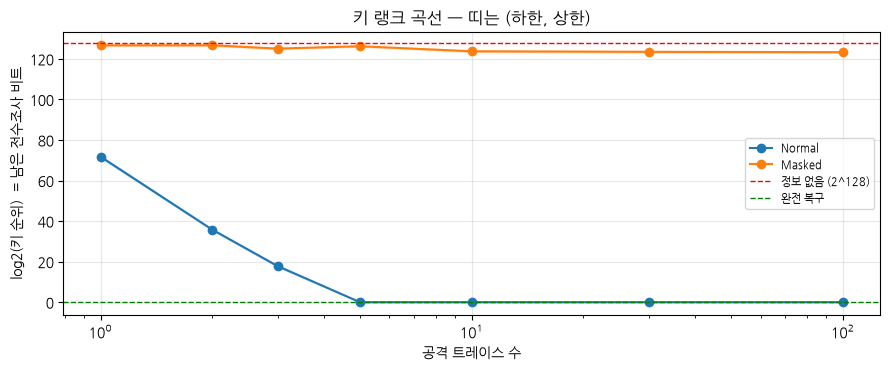

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for tid in rank_curve:
    ms = [r[0] for r in rank_curve[tid]]
    lo = [np.log2(max(r[1], 1)) for r in rank_curve[tid]]
    mid = [np.log2(max(r[2], 1)) for r in rank_curve[tid]]
    hi = [np.log2(max(r[3], 1)) for r in rank_curve[tid]]
    line, = ax.plot(ms, mid, "o-", label=TARGETS[tid]["short"])
    ax.fill_between(ms, lo, hi, alpha=0.2, color=line.get_color())
ax.axhline(128, color="r", ls="--", lw=1, label="정보 없음 (2^128)")
ax.axhline(0, color="g", ls="--", lw=1, label="완전 복구")
ax.set_xscale("log"); ax.set_xlabel("공격 트레이스 수")
ax.set_ylabel("log2(키 순위)  = 남은 전수조사 비트")
ax.set_title("키 랭크 곡선 — 띠는 (하한, 상한)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 3. `rank_accuracy` 와 `rank_nbin`

두 함수가 같은 답을 내는지, 정확도를 올리면 얼마나 느려지는지 본다.

In [5]:
tid0 = list(probas)[0]
costs = to_costs(key_logprob_all(tid0, 3))

print("=== %s, 공격 3장 ===" % TARGETS[tid0]["short"])
for acc in (2.0, 1.0, 0.5):
    t0 = time.time()
    rmin, r, rmax = rank_accuracy(costs, TRUE_KEY, acc_bit=acc)
    print("  rank_accuracy(acc_bit=%.1f)  %6.2f 초  log2: %.2f ~ %.2f ~ %.2f"
          % (acc, time.time() - t0, np.log2(max(rmin, 1)),
             np.log2(max(r, 1)), np.log2(max(rmax, 1))))
for nb in (2 ** 12, 2 ** 16, 2 ** 20):
    t0 = time.time()
    rmin, r, rmax = rank_nbin(costs, TRUE_KEY, nb)
    print("  rank_nbin(nbins=%-8d)  %6.2f 초  log2: %.2f ~ %.2f ~ %.2f"
          % (nb, time.time() - t0, np.log2(max(rmin, 1)),
             np.log2(max(r, 1)), np.log2(max(rmax, 1))))
print()
print("빈을 늘리면 하한·상한이 좁아지고 계산이 느려진다. 정확도와 시간의 교환이다.")

=== Normal, 공격 3장 ===
  rank_accuracy(acc_bit=2.0)    0.03 초  log2: 16.97 ~ 17.85 ~ 18.69
  rank_accuracy(acc_bit=1.0)    0.05 초  log2: 17.39 ~ 17.81 ~ 18.22
  rank_accuracy(acc_bit=0.5)    0.06 초  log2: 17.62 ~ 17.83 ~ 18.03
  rank_nbin(nbins=4096    )    0.01 초  log2: 17.81 ~ 17.82 ~ 17.83


  rank_nbin(nbins=65536   )    0.05 초  log2: 17.82 ~ 17.82 ~ 17.82


  rank_nbin(nbins=1048576 )    0.88 초  log2: 17.82 ~ 17.82 ~ 17.82

빈을 늘리면 하한·상한이 좁아지고 계산이 느려진다. 정확도와 시간의 교환이다.


---
## 4. 결론 — 시리즈 전체의 요약

이 노트북의 숫자가 1.0부터 이어 온 모든 분석의 결론이다.

In [6]:
print("=" * 68)
print("공격 트레이스 %d장에서 남은 전수조사 규모" % N_USE)
print("=" * 68)
for tid in probas:
    costs = to_costs(key_logprob_all(tid, N_USE))
    rmin, r, rmax = rank_accuracy(costs, TRUE_KEY, acc_bit=1.0)
    print("  %-8s  2^%.1f  (%.3g 개 후보)" % (
        TARGETS[tid]["short"], np.log2(max(r, 1)), r))
print()
if len(probas) == 2:
    c_n = to_costs(key_logprob_all("tiny-AES-c", N_USE))
    c_m = to_costs(key_logprob_all("masked-aes-c", N_USE))
    _, r_n, _ = rank_accuracy(c_n, TRUE_KEY, acc_bit=1.0)
    _, r_m, _ = rank_accuracy(c_m, TRUE_KEY, acc_bit=1.0)
    print("  Normal 은 사실상 끝났고, Masked 는 전수조사가 그대로 남아 있다.")
    print("  차이 %.1f 비트." % (np.log2(max(r_m, 1)) - np.log2(max(r_n, 1))))
    print()
    print("  단, 이것은 **1차 공격자 관점**의 결과다. 같은 파형에서")
    print("  마스크를 아는 쪽은 키를 복구했다 (1.0 §10, 3.0 §6, 4.0 §6).")
    print("  마스킹이 지키는 것은 알고리즘이 아니라 난수의 비밀이다.")

공격 트레이스 3장에서 남은 전수조사 규모
  Normal    2^17.8  (2.3e+05 개 후보)
  Masked    2^125.1  (4.49e+37 개 후보)



  Normal 은 사실상 끝났고, Masked 는 전수조사가 그대로 남아 있다.
  차이 107.3 비트.

  단, 이것은 **1차 공격자 관점**의 결과다. 같은 파형에서
  마스크를 아는 쪽은 키를 복구했다 (1.0 §10, 3.0 §6, 4.0 §6).
  마스킹이 지키는 것은 알고리즘이 아니라 난수의 비밀이다.


---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 부분키 점수들을 합쳐 **128비트 키 전체의 순위**를 추정한다 |
| API | `rank_accuracy(costs, key, acc_bit)` · `rank_nbin(costs, key, nbins)` |
| `costs` | `(16, 256)` **작을수록 좋음**. 보통 $-\log \Pr$ |
| 반환 | `(하한, 추정, 상한)` — 근사이므로 구간 |
| 읽는 법 | $\log_2(\text{순위})$ = 남은 전수조사 비트 |

### 전체 흐름 되짚기

```text
0.0 / 0.1  수집 (하드웨어)
    │
   1.0 SNR ─── 누설 위치 + 암호화 구간 경계(enc_start) + POI
    │
   1.1 Quantizer ── int16 변환이 정보를 지키는가
    │
   2.0 Ttest ───── 누설 유무 진단. 구간을 나눠야 마스킹이 보인다
   2.1 MTtest ──── 시점 조합. 2차 공격의 비용
    │
   3.0 CPA ─────── 가정 기반 키 복구
   4.0 LDA ─────── 측정 기반 키 복구 (1바이트)
   4.1 MultiLDA ── 16바이트 동시
   4.2 RLDA ────── 학습 트레이스가 적을 때 · 정보량 비트
   5.0 SASCA ───── 그래프로 정보 합치기
    │
   6.0 KeyRank ─── 남은 전수조사 규모 (여기)
```

각 단계는 Normal 과 Masked 를 나란히 비교했고, 공격 셀은 `i_m` 을 쓰지 않았다.
`i_m` 을 쓰는 절은 언제나 "연구자" 로 따로 표시했다.

### 실패 시 점검

1. `costs` 의 부호를 뒤집지 않으면(확률을 그대로 넣으면) 순위가 반대로 나온다.
2. 바이트별 로그확률을 정규화하지 않으면 한 바이트가 전체를 지배한다.
3. 추정 구간이 너무 넓다 → `acc_bit` 을 줄이거나 `nbins` 를 늘린다. 대신 느려진다.